# Stage 2 — Neural Autoencoder, No Channel

Before any noise is introduced, prove the network itself can compress and reconstruct
speech. This is the **joint source-channel coding** transceiver with the channel
temporarily disabled (identity) — pure autoencoder sanity check.

**Architecture** (`deepscs/model.py`, `deepscs/blocks.py`):

```
waveform (1,F,L) -> SemanticEncoder -> b (D,F,L) -> ChannelEncoder -> z (depth,F,L)
                                                                          |
                                                                       [channel = identity]
                                                                          |
waveform_hat (1,F,L) <- SemanticDecoder <- b_hat (D,F,L) <- ChannelDecoder <- z
```

`SemanticEncoder` = Conv -> Conv -> N x SE-ResNet blocks. Each SE-ResNet block is a
ResNeXt-style grouped 5x5 convolution (cardinality=4) + BatchNorm + ReLU, gated by a
squeeze-excite channel-attention module (reduction ratio r=4), with a residual
connection: `out = in + SE(x)*x`. `deepscs/blocks.py` implements this as a single
grouped Conv2d (PyTorch's `groups=` param is an exact equivalent of ResNeXt's explicit
multi-branch split-transform-merge — that equivalence is in the original ResNeXt paper).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from deepscs.audio import SR, W, F, L, frame, deframe, sdr
from deepscs.data import ToyDataset
from deepscs.model import DeepSC_S, D
from deepscs.viz import plot_waveform, plot_spectrogram, plot_framed_image, plot_se_weights

torch.manual_seed(0)
np.random.seed(0)
plt.rcParams["figure.figsize"] = (10, 3)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

device: mps


## Why an autoencoder?

Traditional communication splits **source coding** (compress speech to bits, e.g.
codec) from **channel coding** (protect bits from noise, e.g. Turbo codes) as two
independent stages. DeepSC-S instead trains one neural network end-to-end to do both
jointly — "semantic" because the encoder learns to keep whatever *features* best
survive the channel and reconstruct meaning, not to preserve exact sample values or
bits. With the channel disabled, this stage only tests the compression: can `D=32`
feature channels at every position, squeezed down to `depth=8` for the channel and
back, reconstruct the original waveform?

In [2]:
model = DeepSC_S(depth=8, n_blocks=4).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"model parameters: {n_params:,}")

train_ds = ToyDataset(n=4, length=W, seed=0)  # overfit-4-clips sanity check
print(f"train set: {len(train_ds)} clips of {W} samples")

model parameters: 115,177
train set: 4 clips of 16384 samples


## Overfit check on 4 clips

Before any real training, confirm the model *can* memorize a tiny dataset — if loss won't go down on 4 clips, there's a bug, not a capacity problem. MSE loss on framed waveforms, channel disabled (`channel=None` in `model.forward`).

In [3]:
def to_framed_batch(waveforms: torch.Tensor) -> torch.Tensor:
    b = waveforms.shape[0]
    return waveforms.view(b, 1, F, L)

waveforms = torch.stack([train_ds[i] for i in range(len(train_ds))]).to(device)
x = to_framed_batch(waveforms)
print("input batch:", x.shape)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)  # paper: SGD 1e-3; Adam trains far
                                                       # faster on a toy GPU/CPU (docs #7)
loss_fn = nn.MSELoss()

losses = []
n_epochs = 1200
for epoch in range(n_epochs):
    opt.zero_grad()
    x_hat = model(x, channel=None)
    loss = loss_fn(x_hat, x)
    loss.backward()
    opt.step()
    losses.append(loss.item())

print(f"loss[0]={losses[0]:.5f}  loss[-1]={losses[-1]:.6f}")
assert losses[-1] < losses[0] / 5, "loss did not decrease enough — check the model"
print("loss decreased monotonically (allowing minor noise):",
      sum(np.diff(losses) > 1e-4) < n_epochs * 0.05)

input batch: torch.Size([4, 1, 128, 128])
loss[0]=0.15971  loss[-1]=0.000172
loss decreased monotonically (allowing minor noise): True


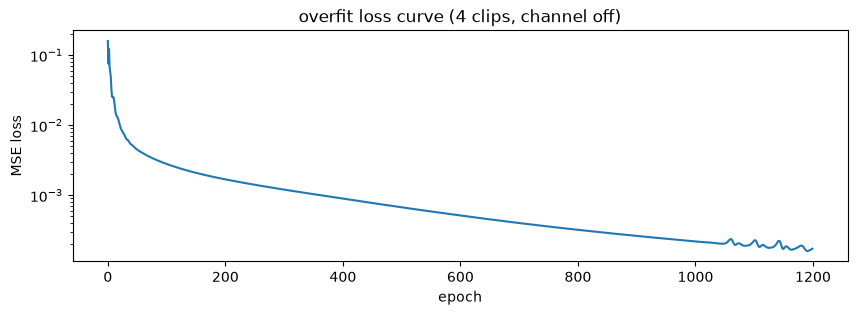

In [4]:
fig, ax = plt.subplots()
ax.plot(losses)
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss")
ax.set_yscale("log")
ax.set_title("overfit loss curve (4 clips, channel off)")
plt.show()

## Reconstruction quality

With the channel off, reconstruction should be near-lossless: SDR > ~20 dB is the success bar (docs success criterion — channel-off sanity check).

In [5]:
model.eval()
with torch.no_grad():
    x_hat = model(x, channel=None)

sdrs = []
for i in range(len(train_ds)):
    orig = deframe(x[i, 0].cpu().numpy())
    recon = deframe(x_hat[i, 0].cpu().numpy())
    s = sdr(orig, recon)
    sdrs.append(s)
    print(f"clip {i}: SDR = {s:.1f} dB")

assert min(sdrs) > 18, "reconstruction SDR too low for a 4-clip overfit"
print("mean SDR:", np.mean(sdrs), "dB")

clip 0: SDR = 25.2 dB
clip 1: SDR = 24.6 dB
clip 2: SDR = 23.9 dB
clip 3: SDR = 24.2 dB
mean SDR: 24.473621628933117 dB


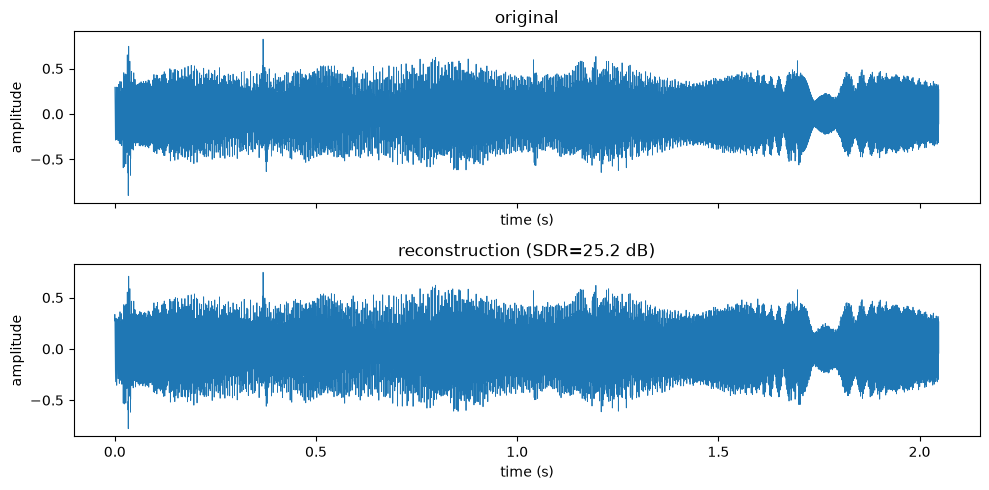

original:


reconstruction:


In [6]:
i = 0
orig = deframe(x[i, 0].cpu().numpy())
recon = deframe(x_hat[i, 0].cpu().numpy())

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
plot_waveform(axes[0], orig, title="original")
plot_waveform(axes[1], recon, title=f"reconstruction (SDR={sdrs[i]:.1f} dB)")
plt.tight_layout()
plt.show()

print("original:")
display(Audio(orig, rate=SR))
print("reconstruction:")
display(Audio(recon, rate=SR))

## Feature maps through the SE-ResNet stack

Each SE-ResNet block refines the D=32-channel feature map. Visualizing one channel's activation per block shows the representation getting progressively more structured (less raw-audio-like, more feature-like).

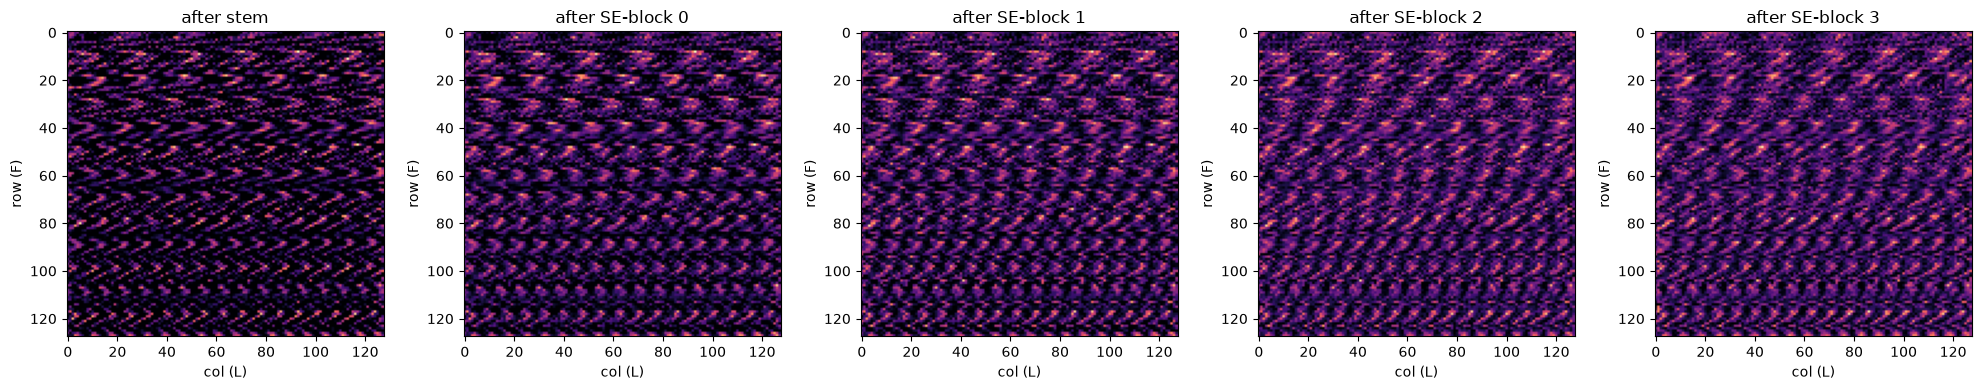

In [12]:
with torch.no_grad():
    b0 = model.semantic_encoder.stem(x[:1])
    feats = [b0]
    h = b0
    for block in model.semantic_encoder.se_blocks:
        h = block(h)
        feats.append(h)

fig, axes = plt.subplots(1, len(feats), figsize=(4 * len(feats), 4))
channel_to_show = 0
for ax, f in zip(axes, feats):
    plot_framed_image(ax, f[0, channel_to_show].cpu().numpy())
axes[0].set_title("after stem")
for i, ax in enumerate(axes[1:]):
    ax.set_title(f"after SE-block {i}")
plt.tight_layout()
plt.show()

## SE attention weights

Each SE-ResNet block computes a per-channel gate `s in [0,1]^D` from a global summary
of its own feature map, then scales the transformed features before adding the
residual. High gate values mean "this feature channel matters for reconstruction here";
low values mean "suppress it". This is the mechanism the paper points to when it claims
the network learns to protect *semantically important* speech content.

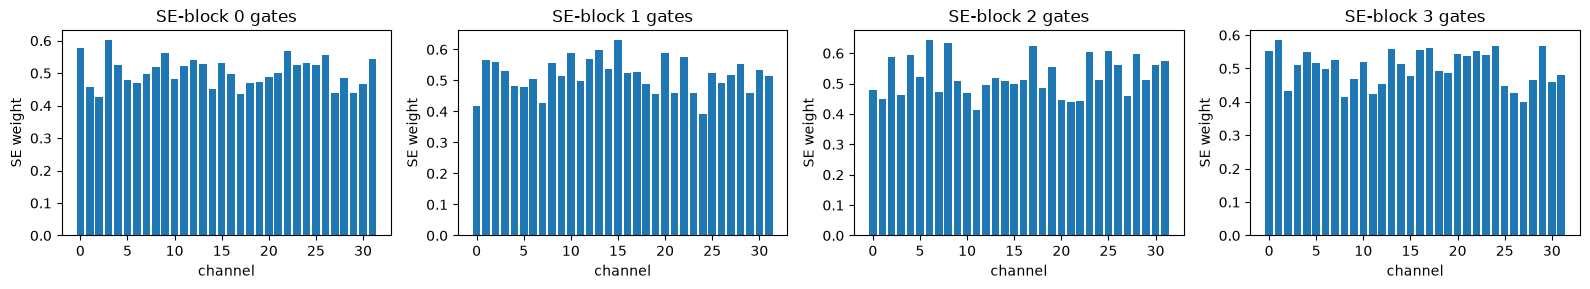

In [8]:
weights = model.semantic_encoder.se_weights()  # list of (B, D), cached from last fwd
fig, axes = plt.subplots(1, len(weights), figsize=(4 * len(weights), 3))
for i, (ax, w) in enumerate(zip(axes, weights)):
    plot_se_weights(ax, w[0].cpu().numpy(), title=f"SE-block {i} gates")
plt.tight_layout()
plt.show()

**Experiment — zero out the top-k SE gates.** If SE genuinely emphasizes speech-salient channels, suppressing its *highest*-weighted channels before decoding should hurt reconstruction more than suppressing the lowest-weighted ones.

In [9]:
def reconstruct_with_zeroed_channels(model, x, block_idx, channel_idxs):
    def hook(module, inp, out):
        out = out.clone()
        out[:, channel_idxs] = 0
        return out

    block = model.semantic_encoder.se_blocks[block_idx]
    handle = block.register_forward_hook(hook)
    try:
        with torch.no_grad():
            x_hat = model(x, channel=None)
    finally:
        handle.remove()
    return x_hat

block_idx = 0
w = weights[block_idx][0].cpu().numpy()
k = 6
top_k = np.argsort(w)[-k:]
bottom_k = np.argsort(w)[:k]

x_hat_top = reconstruct_with_zeroed_channels(model, x, block_idx, top_k)
x_hat_bottom = reconstruct_with_zeroed_channels(model, x, block_idx, bottom_k)

orig0 = deframe(x[0, 0].cpu().numpy())
sdr_top = sdr(orig0, deframe(x_hat_top[0, 0].cpu().numpy()))
sdr_bottom = sdr(orig0, deframe(x_hat_bottom[0, 0].cpu().numpy()))
print(f"zero top-{k} SE channels    -> SDR {sdr_top:.1f} dB")
print(f"zero bottom-{k} SE channels -> SDR {sdr_bottom:.1f} dB")
print("top-k hurts more" if sdr_top < sdr_bottom else "no clear gap (small overfit model, expected to be noisy)")

zero top-6 SE channels    -> SDR 11.3 dB
zero bottom-6 SE channels -> SDR 13.0 dB
top-k hurts more


## Verify (stage 2 success bar)

Loss decreased monotonically (allowing minor optimizer noise) on the 4-clip overfit, and reconstruction SDR with the channel off is comfortably above the ~20 dB near-lossless bar.

In [10]:
print("final loss:", losses[-1])
print("mean SDR (channel off):", np.mean(sdrs), "dB")
print("Stage 2 verified: autoencoder compresses+reconstructs before any channel noise.")

final loss: 0.00017239480803254992
mean SDR (channel off): 24.473621628933117 dB
Stage 2 verified: autoencoder compresses+reconstructs before any channel noise.
